# Helpful websites:

- https://pygridgen.readthedocs.io/en/latest/tutorial/basics.html
- https://pygridtools.readthedocs.io/en/latest/
- https://epsg.org
- https://pyoceans.github.io/sea-py/
- https://app.sandbox.dea.ga.gov.au/hub/spawn-pending/dpath2o
- https://www.soest.hawaii.edu/pwessel/gshhg/
- https://pyproj4.github.io/pyproj/stable/index.html
- https://automating-gis-processes.github.io/CSC18/lessons/L4/point-in-polygon.html
- https://stackoverflow.com/questions/2964751/how-to-convert-a-geos-multilinestring-to-polygon
- https://gis.stackexchange.com/questions/223447/welding-individual-line-segments-into-one-linestring-using-shapely
- https://ocefpaf.github.io/python4oceanographers/blog/2015/08/17/shapely_in_polygon/

# IMPORT LIBRARIES

In [1]:
import os
import warnings
warnings.simplefilter('ignore')
from scipy.ndimage.filters import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns
import pygmt
import cartopy
import cartopy.feature as cfeature
from cartopy.io import shapereader
import cmocean
from shapely.geometry import Polygon, Point , mapping, shape
from shapely.ops import linemerge
import shapely.speedups
from shapely.prepared import prep
from pyproj import Proj, transform
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray
import pygridgen as pgg
import pygridtools as pgt

# INPUT PARAMETERS

In [2]:
Droot        = os.path.join('/','home','dpath2o')
Dbin         = os.path.join(Droot,'anaconda3','envs','EAFIM','bin')
Djupyter     = os.path.join(Droot,'jupyter')
BinOGR       = os.path.join(Dbin,'ogr2ogr')
Fcstin       = os.path.join(Djupyter,'EAFIM','coastlines','AusCst','DEACoastlines_annualcoastlines_v1.0.0.shp')
Fcstout      = os.path.join(Djupyter,'EAFIM','coastlines','AusCst','DEACoastline_jervisbay.shp')
nx           = 100
ny           = nx
epsg_WGS     = 4326 #WGS 84
epsg_AA      = 3577 #AUSTRALIAN AULBERS
epsg_WGS_str = 'epsg:{:d}'.format(epsg_WGS) 
epsg_AA_str  = 'epsg:{:d}'.format(epsg_AA)
proj_WGS     = Proj(init=epsg_WGS_str)
proj_AA      = Proj(init=epsg_AA_str)
blocs        = np.array([(150.87 , -34.59),
                        (150.44 , -35.4),
                        (151.5  , -36),
                        (152.5  , -34.5),
                        (150.87 , -34.59)])
bbetas       = np.array([1,
                       1,
                       1,
                       1,
                       0])

# Generate the grid

In [3]:
bndry        = pd.DataFrame({'beta':bbetas,
                            'longitudes':blocs[:,0],
                            'latitudes':blocs[:,1],
                            'x':blocs[:,0],
                            'y':blocs[:,1]})
bndry_pts    = gpd.GeoDataFrame(bndry,
                                geometry=gpd.points_from_xy(bndry.x,bndry.y),
                                crs=epsg_WGS_str)
bndry_ply    = gpd.GeoDataFrame(geometry=gpd.GeoSeries([Polygon(blocs)]),
                                crs=epsg_WGS_str)
AA_bndry_pts = bndry_pts.to_crs(epsg_AA_str)
AA_bndry_ply = bndry_ply.to_crs(epsg_AA_str)
bndry_lons   = AA_bndry_pts.geometry.x.to_numpy()
#bndry_lons   = bndry_pts.geometry.x.to_numpy()
bndry_lats   = AA_bndry_pts.geometry.y.to_numpy()
#bndry_lats   = bndry_pts.geometry.y.to_numpy()
GRID         = pgg.Gridgen(bndry_lons,
                           bndry_lats,
                           bbetas,
                           shape=(nx,ny))

# Load the coast and put the grid points geopandas

In [ ]:
# ogr2ogr produces an empty file and geopandas works. So just load the entire coastline
# and then clip it with geopandas. Keep this code here if we want to try to optimise this
# in the future.
#ext_str = '-clipsrc {:10.10f} {:10.10f} {:10.10f} {:10.10f}'.format(extent[0],extent[2],extent[1],extent[3])
#syscall = '{:s} {:s} {:s} {:s}'.format( BinOGR , ext_str , Fcstout , Fcstin )
#os.system(syscall)
#jb_cst = gpd.read_file(Fcstout)
CSTall  = gpd.read_file(Fcstin) 
cst     = CSTall.clip(AA_bndry_ply).reset_index()
cstply  = cst.convex_hull
grd_pts = [Point(point) for point in zip(GRID.x.ravel(), GRID.y.ravel())]
grd_gpd = gpd.GeoDataFrame(crs=epsg_AA_str, geometry=grd_pts)
CSTall  = []

# Plot the un-masked grid

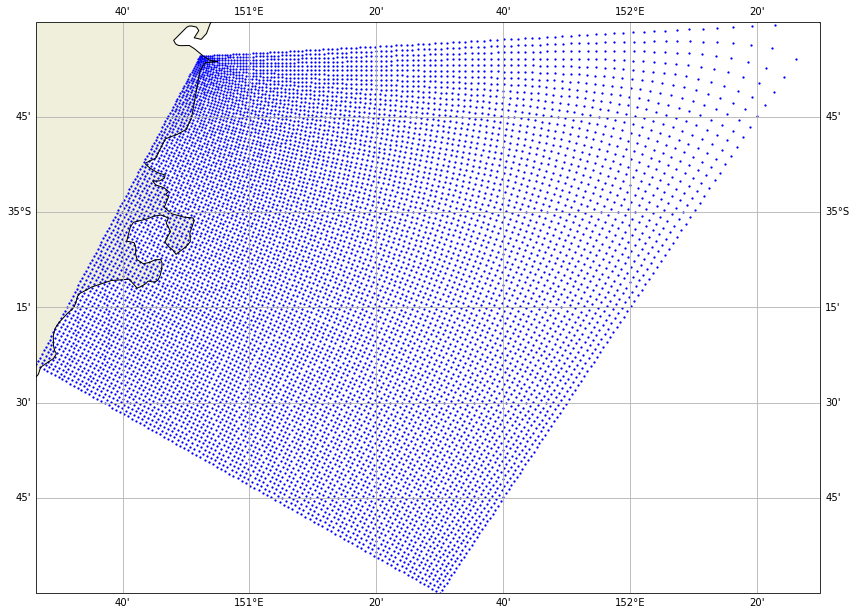

In [4]:
ccrs = cartopy.crs.PlateCarree()
extent = (np.min(GRID.x),np.max(GRID.x),np.min(GRID.y),np.max(GRID.y))
ax = plt.axes(projection=ccrs)
ax.set_extent(extent,crs=ccrs)
ax.add_feature(cfeature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
plt.scatter(GRID.x,GRID.y,s=6,c='b',marker='.',transform=ccrs)
ax.coastlines(resolution='10m')
f = plt.gcf()
f.set_size_inches(18.5, 10.5)

# Mask with cartopy and geopandas

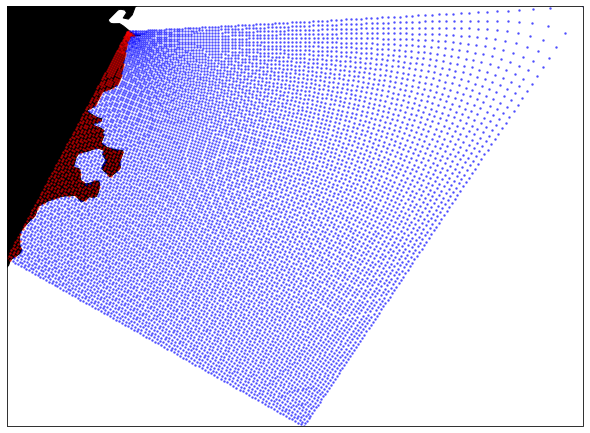

In [7]:
land_10m = cartopy.feature.NaturalEarthFeature('physical', 'land', '10m')
land_polygons = list(land_10m.geometries())
land_polygons_prep = [prep(land_polygon) for land_polygon in land_polygons]
points = [Point(point) for point in zip(GRID.x.ravel(), GRID.y.ravel())]
land = []
for land_polygon in land_polygons_prep:
    land.extend([tuple(point.coords)[0] for point in filter(land_polygon.covers, points)])
sea = set([tuple(point.coords)[0] for point in points]) - set(land)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_axes([0, 0, 1, 1], projection=ccrs)
ax.set_extent(extent,crs=ccrs)
ax.add_feature(land_10m, zorder=0, edgecolor='black', facecolor=sns.xkcd_rgb['black'])
xl,yl = zip(*land)
ax.scatter(xl, yl, transform=ccrs, s=10, marker='.', c='red', alpha=0.5, zorder=2)
xs, ys = zip(*sea)
ax.scatter(xs, ys, transform=ccrs, s=10, marker='.', c='blue', alpha=0.5, zorder=2)
# original projection
#p = pyproj.Proj("+proj=stere +lat_0=90 +lat_ts=60 +lon_0=-105 +k=90 +x_0=0 +y_0=0 +a=6371200 +b=6371200 +units=m +no_defs")
points = [xs,ys]
x = y = []
for lon,lat in zip(*points):
    xtmp,ytmp = transform(proj_WGS,proj_AA,lon,lat)
    x.append(xtmp)
    y.append(ytmp)

In [65]:
da = xr.Dataset({'angle':(['x','y'],GRID.angle),
                 #'angle_rho':(['x','y'],GRID.angle_rho),
                 'xx'   :(['x','y'],GRID.x),
                 'yy'   :(['x','y'],GRID.y)},
                 coords={'lon':(['x','y'],GRID.x),
                         'lat':(['x','y'],GRID.y)})

In [95]:
da

<xarray.Dataset>
Dimensions:  (x: 100, y: 100)
Coordinates:
    lon      (x, y) float64 1.751e+06 1.753e+06 ... 1.718e+06 1.718e+06
    lat      (x, y) float64 -4.067e+06 -4.066e+06 ... -3.904e+06 -3.904e+06
Dimensions without coordinates: x, y
Data variables:
    angle    (x, y) float64 0.8652 0.9068 0.9108 0.9124 ... 1.037 1.057 1.249
    xx       (x, y) float64 1.751e+06 1.753e+06 ... 1.718e+06 1.718e+06
    yy       (x, y) float64 -4.067e+06 -4.066e+06 ... -3.904e+06 -3.904e+06

In [98]:
grd_ex = xr.open_dataset('/home/dpath2o/ROMS/Data/ROMS/Grid/test_head_curv_grd.nc')

In [169]:
grd_ex

<xarray.Dataset>
Dimensions:    (one: 1, two: 2, bath: 1, eta_rho: 28, xi_rho: 58, eta_psi: 27, xi_psi: 57, eta_u: 28, xi_u: 57, eta_v: 27, xi_v: 58)
Dimensions without coordinates: one, two, bath, eta_rho, xi_rho, eta_psi, xi_psi, eta_u, xi_u, eta_v, xi_v
Data variables: (12/44)
    xl         (one) float64 4.83e+04
    el         (one) float64 2.4e+04
    JPRJ       (two) |S1 b'M' b'E'
    PLAT       (two) float32 9.969e+36 9.969e+36
    PLONG      (one) float32 9.969e+36
    ROTA       (one) float32 9.969e+36
    ...         ...
    lon_v      (eta_v, xi_v) float64 0.008522 0.02496 0.04067 ... 0.4273 0.442
    mask_rho   (eta_rho, xi_rho) float64 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    mask_u     (eta_u, xi_u) float64 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    mask_v     (eta_v, xi_v) float64 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    mask_psi   (eta_psi, xi_psi) float64 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    angle      (eta_rho, xi_rho) float64 0.0007327 0.0007327 ... -0.001348
Attributes:
    type:         ROMS GRID file
    title:        Sediment Test Headland Case, Curvilinear Grid
    history:      Created by "mat2roms_rps" on 26-Jan-2006 09:30:13
    CPP-options:  DCOMPLEX, DBLEPREC, NCARG_32, PLOTS,

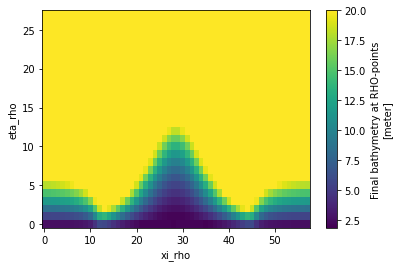

In [104]:
grd_ex.h.plot()

In [18]:
dir(GRID)

['__class__',
 '__del__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_focus',
 '_gn',
 '_libgridgen',
 '_mask',
 '_mask_rho',
 '_nsigmas',
 '_nx',
 '_ny',
 '_sigmas',
 '_x',
 '_y',
 'angle',
 'angle_rho',
 'beta',
 'calculate_orthogonality',
 'checksimplepoly',
 'dmde',
 'dndx',
 'dx',
 'dy',
 'focus',
 'from_spec',
 'generate_grid',
 'mask',
 'mask_polygon',
 'mask_psi',
 'mask_rho',
 'mask_u',
 'mask_v',
 'newton',
 'nnodes',
 'nppe',
 'nsigmas',
 'nx',
 'ny',
 'orthogonality',
 'pm',
 'pn',
 'precision',
 'proj',
 'shape',
 'sigmas',
 'thin',
 'to_spec',
 'ul_idx',
 'verbose',
 'x',
 'x_psi',
 'x_rho',
 'x_u',
 'x_v',
 'x_vert',
 'xbry',
 'y',
 'y_psi',
 'y_rho',
 'y_u',
 '

In [7]:
GRID.y.shape

(100, 100)

In [175]:
grd_ex_ole = xr.open_dataset('./waom2extend_grd.nc')
grd_ex_ole

<xarray.Dataset>
Dimensions:    (eta_rho: 2800, xi_rho: 3150, eta_psi: 2799, xi_psi: 3149, eta_u: 2800, xi_u: 3149, eta_v: 2799, xi_v: 3150)
Dimensions without coordinates: eta_rho, xi_rho, eta_psi, xi_psi, eta_u, xi_u, eta_v, xi_v
Data variables: (12/24)
    spherical  int64 ...
    xl         int64 ...
    el         int64 ...
    angle      (eta_rho, xi_rho) float64 ...
    pm         (eta_rho, xi_rho) float64 ...
    pn         (eta_rho, xi_rho) float64 ...
    ...         ...
    lon_v      (eta_v, xi_v) float64 ...
    lat_v      (eta_v, xi_v) float64 ...
    mask_rho   (eta_rho, xi_rho) float64 ...
    mask_psi   (eta_psi, xi_psi) float64 ...
    mask_u     (eta_u, xi_u) float64 ...
    mask_v     (eta_v, xi_v) float64 ...
Attributes:
    history:  GRID file using make_grid.py,2021-04-24
    type:     ROMS grid file

In [ ]:
grd_ex_ole.mask_psi.plot()

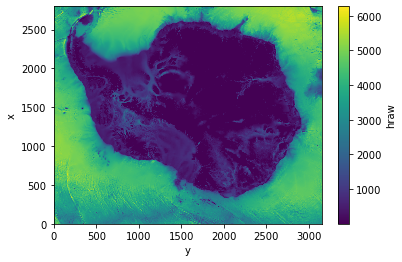

In [212]:
fig=[]
ax=[]
lon = grd_ex_ole.lon_rho.values
lat = grd_ex_ole.lat_rho.values
OLE_BATH = xr.Dataset({'hraw':(['x','y'],grd_ex_ole.hraw.data)},
                       coords={'lon':(['x','y'],lon),
                               'lat':(['x','y'],lat)})
OLE_BATH.hraw.plot()
# proj_AzEq = cartopy.crs.AzimuthalEquidistant()
# fig = plt.figure(1,figsize=(10,12),facecolor='w')  
# ax  = plt.axes(projection=proj_AzEq)
# gl = ax.gridlines(crs=ccrs,draw_labels=True,linewidth=2,color='black',alpha=0.0, linestyle='--')
# gl.top_labels = gl.right_labels = False
# cf = ax.contourf(lon, lat, OLE_BATH.hraw, 256,
#                  cmap=cmocean.cm.topo,
#                  transform=proj_AzEq,
#                  latlon=True,vmin=-6000,vmax=6000,extend="both")
#fig = pygmt.Figure()
#fig.grdimage(grid=OLE_BATH.hraw,frame=["xaf", "yaf", "WSne"],projection="R12c",cmap="geo")
#fig.grdview(
#    grid=elv,
    # Set the azimuth to -130 (230) degrees and the elevation to 30 degrees
#    perspective=[130, 30],
#    frame=["xaf", "yaf", "WSnE"],
#    projection="M15c",
#    zsize="1.5c",
#    surftype="s",
#    cmap="geo",
#    plane="1000+ggrey",
    # Set the contour pen thickness to "0.1p"
#    contourpen="0.1p",
#)
#fig.plot(xs,ys,style="c0.05c", color="red")
#fig.show()

In [111]:
GEBCO = xr.open_dataset('../bathymetry/GEBCO_2021_AustraliaStation.nc')

In [112]:
GEBCO

<xarray.Dataset>
Dimensions:    (lat: 10819, lon: 12104)
Coordinates:
  * lat        (lat) float64 -51.36 -51.35 -51.35 -51.34 ... -6.29 -6.285 -6.281
  * lon        (lon) float64 108.2 108.2 108.2 108.2 ... 158.6 158.6 158.6 158.6
Data variables:
    elevation  (lat, lon) int16 ...
Attributes: (12/36)
    title:                           The GEBCO_2021 Grid - a continuous terra...
    summary:                         The GEBCO_2021 Grid is a continuous, glo...
    keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
    Conventions:                     CF-1.6, ACDD-1.3
    id:                              DOI: 10.5285/c6612cbe-50b3-0cff-e053-6c8...
    naming_authority:                https://dx.doi.org
    ...                              ...
    geospatial_vertical_units:       meters
    geospatial_vertical_resolution:  1.0
    geospatial_vertical_positive:    up
    identifier_product_doi:          DOI: 10.5285/c6612cbe-50b3-0cff-e053-6c8...
    references:                      DOI: 10.5285/c6612cbe-50b3-0cff-e053-6c8...
    node_offset:                     1.0

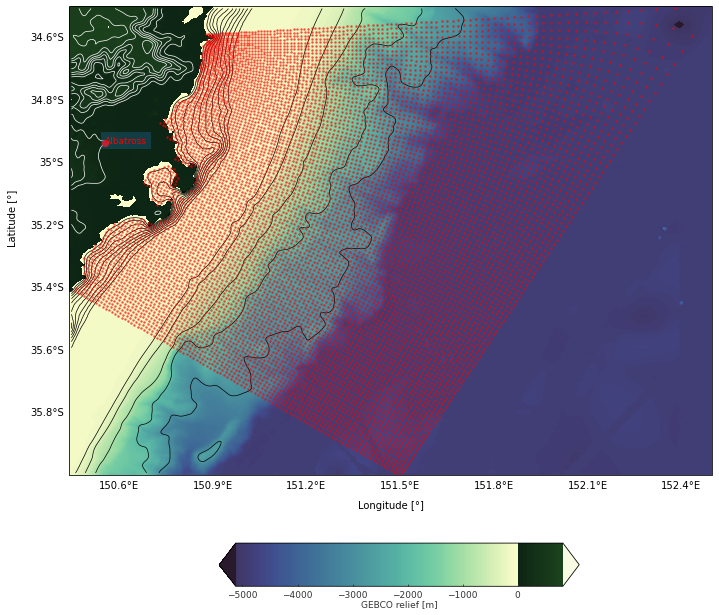

In [140]:
###### slice bathymetry to required region and pull variables out of object
bath = GEBCO.sel(lon=slice(np.min(blocs[:,0]),np.max(blocs[:,0])),
                 lat=slice(np.min(blocs[:,1]),np.max(blocs[:,1])))  
lon = bath.lon
lat = bath.lat
elv = bath.elevation
# figure
fig = plt.figure(1,figsize=(10,12),facecolor='w')  
ax  = plt.axes(projection=ccrs)
ax.set_extent(extent,crs=ccrs)
gl = ax.gridlines(crs=ccrs,draw_labels=True,linewidth=2,color='black',alpha=0.0, linestyle='--')
gl.top_labels = gl.right_labels = False
# add contours with a gaussian filter to smooth
bath_contours = [-3000,-2000,-1000,-500,-250,-100,-90,-80,-70,-60,-50,-40,-30,-20,-10]
ct1 = ax.contour(gaussian_filter(lon,2),
                gaussian_filter(lat,2),
                gaussian_filter(elv,2),
                bath_contours,
                colors='black',latlon=True,linewidths=0.7,linestyles='solid')
# add a reference point ['albatross','sydney']
#ct1_label_locs = [(150.5563,-34.9382),(151.2093,-33.8688)] 
#ct1_label_ax   = plt.clabel(ct1,fmt='%i',fontsize=9,manual=ct1_label_locs,colors="black")
# dry land 
topo_contours = np.arange(100,3000,100)
ct2 = ax.contour(gaussian_filter(lon,2),
                 gaussian_filter(lat,2),
                 gaussian_filter(elv,2),
                 topo_contours,
                 colors='white',latlon=True,linewidths=0.7,linestyles='solid')

#ct2_label_locs = [(-49.3,-28.2),(-49.9,-27.2)]       
#ct2_label_ax   = plt.clabel(Ct2,fmt='%i', fontsize=9, manual=ct2_label_locs,colors="white")
# Plot ETOPO1 data using beautiful cmocean color pallete.
cf = ax.contourf(lon, lat, elv, 256,
                 cmap=cmocean.cm.topo,
                 transform=ccrs,
                 latlon=True,vmin=-6000,vmax=6000,extend="both")
# Add Latitude/Longitude text labels.
ax.text(-0.08, 0.55, 'Latitude'u' [\N{DEGREE SIGN}]', va='bottom', ha='center', rotation='vertical', rotation_mode='anchor',transform=ax.transAxes)
ax.text(0.5, -0.075, 'Longitude'u' [\N{DEGREE SIGN}]', va='bottom', ha='center',rotation='horizontal', rotation_mode='anchor',transform=ax.transAxes)
# Add text and marker to highlight a location.
ax.text(150.5563,-34.9382,'Albatross',color='red',fontsize=9,bbox=dict(fill=True, edgecolor='black', linewidth=0,alpha=0.3))
ax.plot(150.5563,-34.9382,color='red', marker='o', linestyle='dashed', linewidth=2, markersize=6)
#ax.text(151.2093,-33.8688,'Sydney',color='red',fontsize=9,bbox=dict(fill=True, edgecolor='black', linewidth=0,alpha=0.3))
#ax.plot(151.2093,-33.8688,color='red', marker='o', linestyle='dashed', linewidth=2, markersize=6)
# Define colobar options (e.g. min/max range, label and where to place into the plot).
# Create min and max data range (and spacing).
clevs  = np.arange(-6000,1000,5)
ticks  = np.arange(min(clevs),max(clevs),1000)  
cax    = fig.add_axes([0.3, 0.1, 0.5, 0.05]) 
cb     = fig.colorbar(cf, cax=cax, orientation="horizontal",panchor=(0.5,0.5),shrink=0.3,ticks=ticks)   
cb.set_label(r'GEBCO relief [m]', fontsize=9, color='0.2',labelpad=0) 
cb.ax.tick_params(labelsize=9, length=2, color='0.2', labelcolor='0.2',direction='in') 
cb.set_ticks(ticks)
ax.scatter(xs, ys, transform=ccrs, s=10, marker='.', c='red', alpha=0.5, zorder=2)
plt.tight_layout()

In [141]:
plt.savefig('eaxa_jervis_bay_with_grid_overlay.png')

<Figure size 432x288 with 0 Axes>

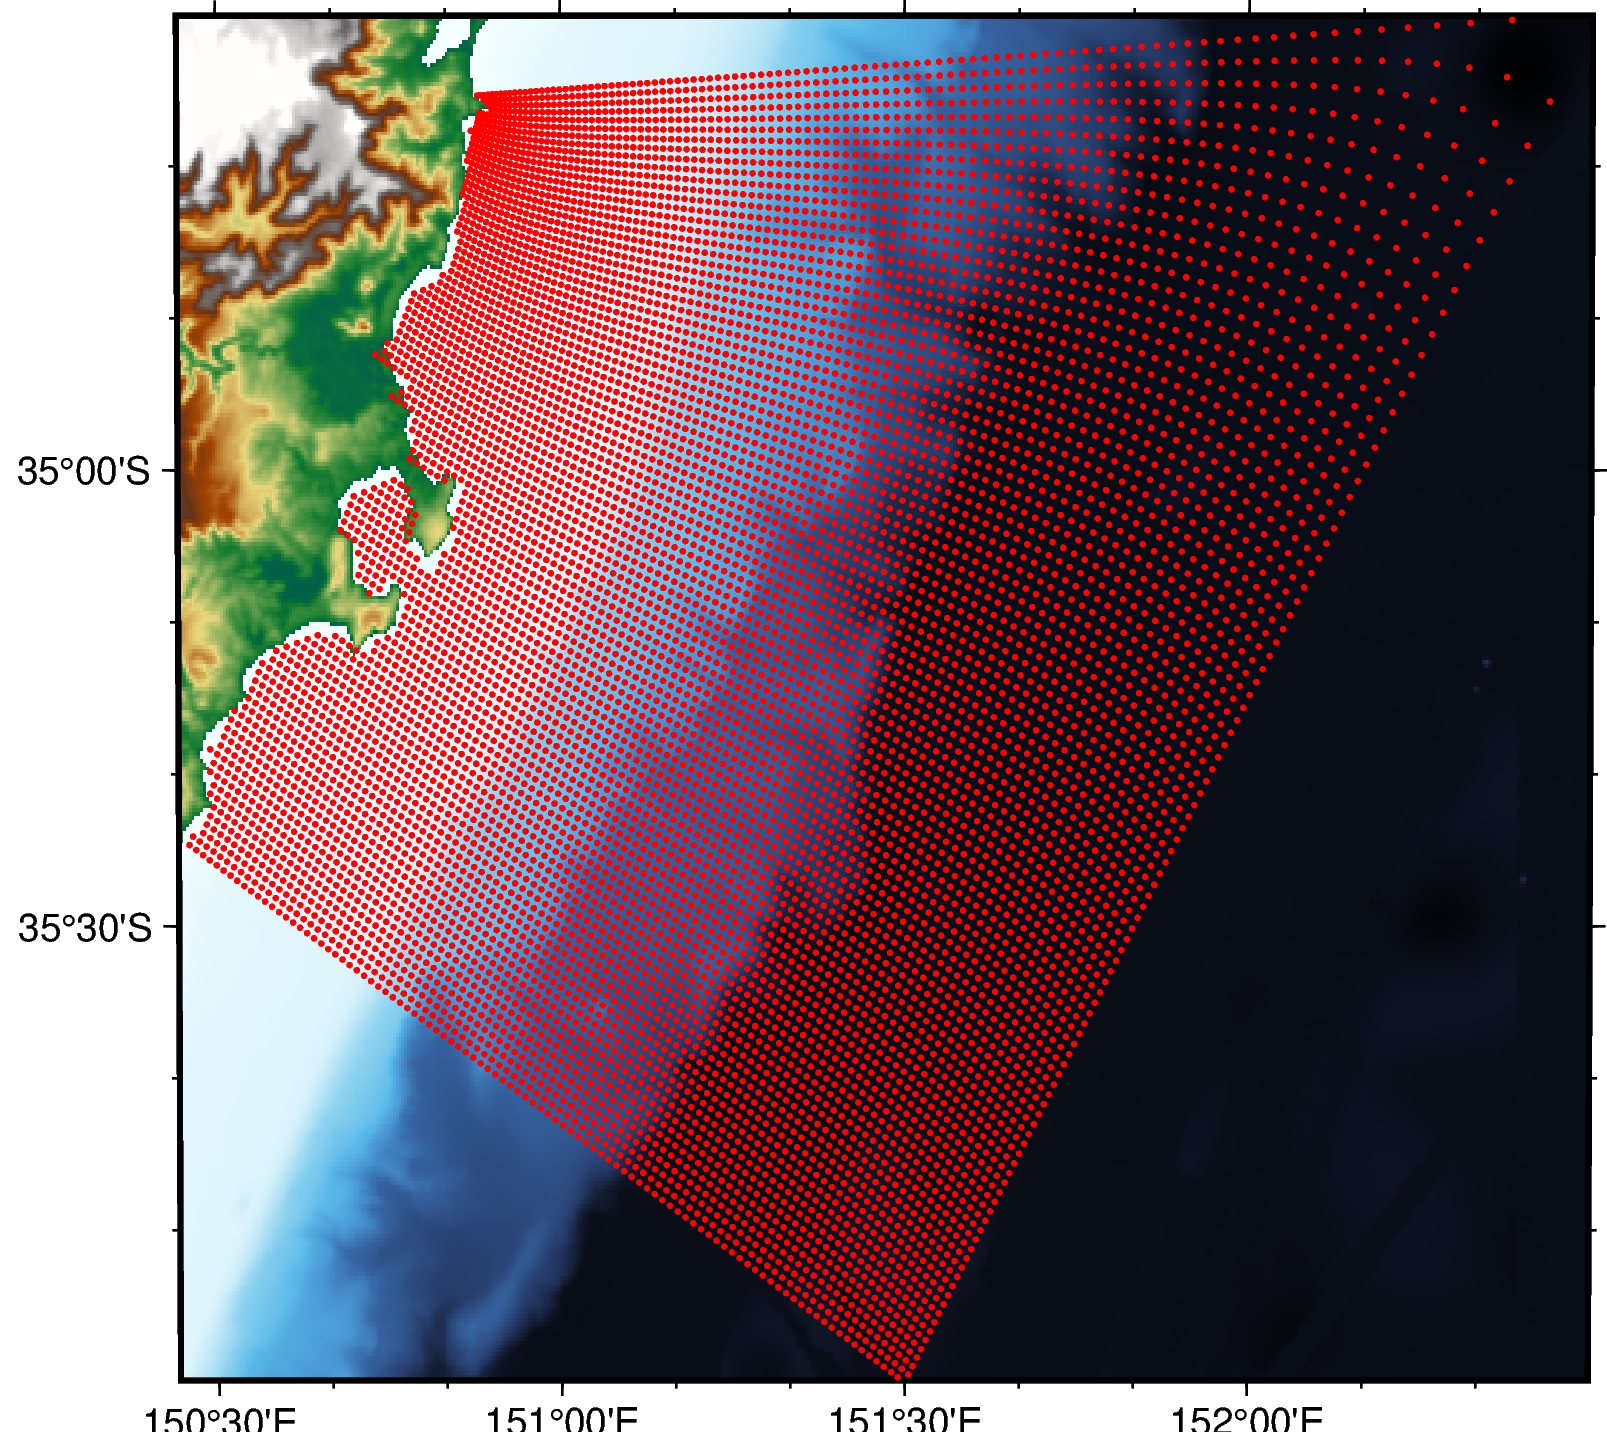

In [166]:
elv = bath.elevation.astype(np.float32)
fig = pygmt.Figure()
fig.grdimage(grid=elv,
             frame=["xaf", "yaf", "WSne"],
             projection="R12c",
             cmap="geo")
#fig.grdview(
#    grid=elv,
    # Set the azimuth to -130 (230) degrees and the elevation to 30 degrees
#    perspective=[130, 30],
#    frame=["xaf", "yaf", "WSnE"],
#    projection="M15c",
#    zsize="1.5c",
#    surftype="s",
#    cmap="geo",
#    plane="1000+ggrey",
    # Set the contour pen thickness to "0.1p"
#    contourpen="0.1p",
#)
fig.plot(xs,ys,style="c0.05c", color="red")
fig.show()

In [ ]:

da = xr.Dataset({'angle':(['x','y'],GRID.angle),
                 #'angle_rho':(['x','y'],GRID.angle_rho),
                 'xx'   :(['x','y'],GRID.x),
                 'yy'   :(['x','y'],GRID.y)},
                 coords={'lon':(['x','y'],GRID.x),
                         'lat':(['x','y'],GRID.y)})